In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage # to delete msgs from convo

In [2]:
load_dotenv()

True

In [21]:
model = ChatGroq(model='llama-3.1-8b-instant')

In [11]:
def chat_node(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6] 
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [12]:
builder = StateGraph(MessagesState)
builder.add_node("chat_node", chat_node)
builder.add_node("cleanup", delete_old_messages)

In [13]:
builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [14]:
graph = builder.compile(checkpointer=InMemorySaver())

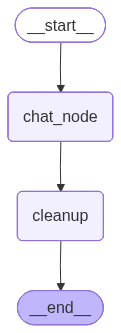

In [15]:
graph

In [16]:
config = {"configurable": {"thread_id": "t1"}}

In [22]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='107d573f-ec72-4cfc-a4bf-ab80d5c64228'),
  AIMessage(content='I don\'t have any information about a specific term called "checkpointers." However, a "checkpoint" is a concept in various fields, including computing, databases, and software development.\n\nIn general, a checkpoint is a point in time where an application or system saves its current state, allowing it to recover from a failure or error in the future. This is often used in distributed systems, databases, and long-running computations to ensure data consistency and prevent data loss.\n\nCheckpointers might refer to the components or entities responsible for creating and managing these checkpoints. However, without more context, it\'s difficult to provide a more specific explanation. Can you provide more information about checkpointers or the context in which you encountered this term, Nitish?', additional_kwargs={},

In [23]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 10


In [24]:
snap.values['messages']

[HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='107d573f-ec72-4cfc-a4bf-ab80d5c64228'),
 AIMessage(content='I don\'t have any information about a specific term called "checkpointers." However, a "checkpoint" is a concept in various fields, including computing, databases, and software development.\n\nIn general, a checkpoint is a point in time where an application or system saves its current state, allowing it to recover from a failure or error in the future. This is often used in distributed systems, databases, and long-running computations to ensure data consistency and prevent data loss.\n\nCheckpointers might refer to the components or entities responsible for creating and managing these checkpoints. However, without more context, it\'s difficult to provide a more specific explanation. Can you provide more information about checkpointers or the context in which you encountered this term, Nitish?', additional_kwargs={}, response_meta